# Stellar Luminosity Hands-on

Linear and polynomial regression implemented from scratch (pure numpy, no sklearn) to study how a star's luminosity relates to its mass.

Small dataset, 10 points inspired by the non-linear shape of the main sequence. Useful for practicing the vectorized gradient descent algorithm, not for drawing real astrophysical conclusions (more on that in section 2).

Structure:

1. Environment and data
2. Exploration before modeling
3. Algorithm functions (predict, cost, gradient, gradient descent)
4. Linear model
5. Polynomial model (mass and mass^2)
6. Comparing both models
7. How far a prediction can be trusted
8. Reflection on AI

## 1. Environment and data

Libraries, versions, and the dataset loaded as numpy arrays.

In [1]:
import sys
import platform

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)
print("OS:", platform.platform())

Python: 3.12.3
NumPy: 2.4.4
Matplotlib: 3.10.8
OS: Linux-6.18.5-x86_64-with-glibc2.39


In [2]:
# dataset for the assignment: mass in solar masses, luminosity in solar luminosities
mass = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
luminosity = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

m = mass.shape[0]

assert mass.shape == luminosity.shape, "mass and luminosity must have the same size"

print("mass.shape:", mass.shape)
print("luminosity.shape:", luminosity.shape)
print("number of examples m =", m)
print()
print("mass  -> min:", mass.min(), " max:", mass.max())
print("lum   -> min:", luminosity.min(), " max:", luminosity.max())

mass.shape: (10,)
luminosity.shape: (10,)
number of examples m = 10

mass  -> min: 0.6  max: 2.4
lum   -> min: 0.15  max: 35.0


## 2. Exploration before modeling

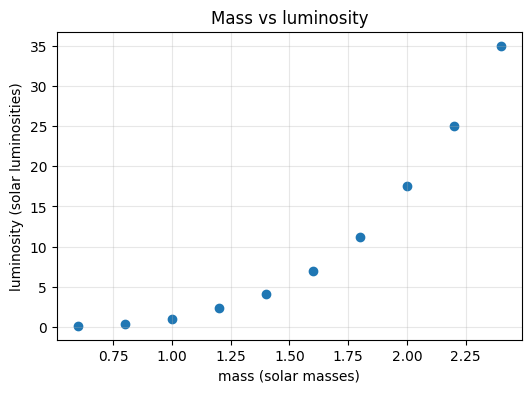

In [3]:
plt.figure(figsize=(6, 4))
plt.scatter(mass, luminosity, color="tab:blue")
plt.xlabel("mass (solar masses)")
plt.ylabel("luminosity (solar luminosities)")
plt.title("Mass vs luminosity")
plt.grid(alpha=0.3)
plt.show()

It's very clear that the relationship is NOT a straight line. At low mass (0.6-1.0) the curve is almost flat, luminosity grows slowly. After mass~1.4 the curve shoots up faster and faster. That's typical of the main sequence, where luminosity scales as a power of mass (something like M^3 - M^4 in real life; here the dataset is made up but follows that same shape).

A straight line can "pass through the middle" of these 10 points, but:

- at low mass the line will be off (the real curve is nearly flat there and a line with a constant positive slope can't be)
- at high mass the line won't be able to rise as fast as the data does

So if we fit a line the expected error will NOT be random, it will have a shape: the model will systematically err in the same direction within each mass zone. We confirm this later by looking at the residuals (sections 4 and 6).

## 3. Algorithm functions (vectorized)

Same functions we saw in class for multivariable regression, generalized to work with 1 or more features (X with shape (m, n)):

- `predict(X, w, b)` = X @ w + b
- `compute_cost(X, y, w, b)` = MSE with the 1/2 factor from the class convention, J(w,b) = (1/2m) * sum(error^2)
- `compute_gradient(X, y, w, b)` = dJ/dw, dJ/db
- `gradient_descent(...)` = runs the loop and stores the cost history

These 4 functions are reused without changing a single line for the linear model (section 4) and for the polynomial one (section 5). The only thing that changes between models is the X matrix we pass in.

In [4]:
def predict(X, w, b):
    """y_hat = X @ w + b. X has shape (m, n), w has shape (n,), b is a scalar."""
    return X @ w + b


def compute_cost(X, y, w, b):
    """MSE with the 1/2 factor (class convention): J = (1/2m) * sum(error^2)."""
    m = X.shape[0]
    error = predict(X, w, b) - y
    return (error @ error) / (2 * m)


def compute_gradient(X, y, w, b):
    """Gradient of J with respect to w and b, vectorized."""
    m = X.shape[0]
    error = predict(X, w, b) - y
    dj_dw = (X.T @ error) / m
    dj_db = np.sum(error) / m
    return dj_dw, dj_db


def gradient_descent(X, y, w_init, b_init, alpha, num_iterations, print_every=None):
    """Runs gradient descent and returns the final w, b and the cost history."""
    w = w_init.copy().astype(float)
    b = float(b_init)
    hist_it = []
    hist_cost = []

    for i in range(num_iterations):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(X, y, w, b)
        hist_it.append(i)
        hist_cost.append(cost)

        if print_every and (i % print_every == 0 or i == num_iterations - 1):
            print(f"iter {i:5d}: cost = {cost:9.4f}")

    return w, b, hist_it, hist_cost

In [5]:
# quick sanity check with w=0, b=0, just to confirm the functions don't blow up
X_smoke = mass.reshape(-1, 1)
w_smoke = np.zeros(X_smoke.shape[1])
b_smoke = 0.0

print("predict (first 3):", predict(X_smoke, w_smoke, b_smoke)[:3])
print("cost:", compute_cost(X_smoke, luminosity, w_smoke, b_smoke))
print("gradient:", compute_gradient(X_smoke, luminosity, w_smoke, b_smoke))

predict (first 3): [0. 0. 0.]
cost: 117.69675
gradient: (array([-21.523]), np.float64(-10.36))


## 4. Linear model

`X_linear = [mass]`, a single feature. No scaling needed: with only one column there's no relative-scale issue between features.

In [6]:
X_linear = mass.reshape(-1, 1)
print("X_linear.shape:", X_linear.shape)

n_lin = X_linear.shape[1]
w_init_lin = np.zeros(n_lin)
b_init_lin = 0.0

alpha_lin = 0.1
iters_lin = 2000

X_linear.shape: (10, 1)


In [7]:
w_lin, b_lin, it_lin, cost_lin = gradient_descent(
    X_linear, luminosity, w_init_lin, b_init_lin, alpha_lin, iters_lin, print_every=200
)

print()
print("final w:", w_lin)
print("final b:", b_lin)
print("final cost:", cost_lin[-1])

iter     0: cost =   70.4969
iter   200: cost =   10.3797
iter   400: cost =    9.8082
iter   600: cost =    9.7954
iter   800: cost =    9.7952
iter  1000: cost =    9.7951
iter  1200: cost =    9.7951
iter  1400: cost =    9.7951
iter  1600: cost =    9.7951
iter  1800: cost =    9.7951
iter  1999: cost =    9.7951

final w: [18.1303]
final b: -16.835454434392684
final cost: 9.795148484848484


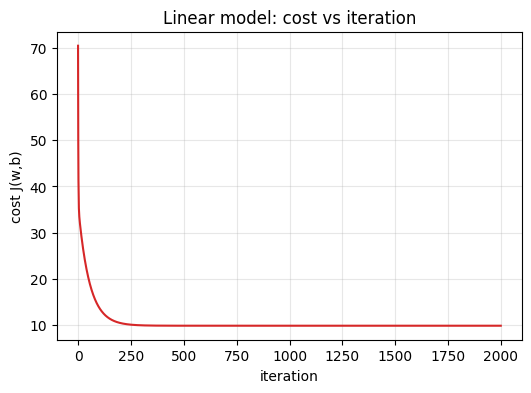

In [8]:
plt.figure(figsize=(6, 4))
plt.plot(it_lin, cost_lin, color="tab:red")
plt.xlabel("iteration")
plt.ylabel("cost J(w,b)")
plt.title("Linear model: cost vs iteration")
plt.grid(alpha=0.3)
plt.show()

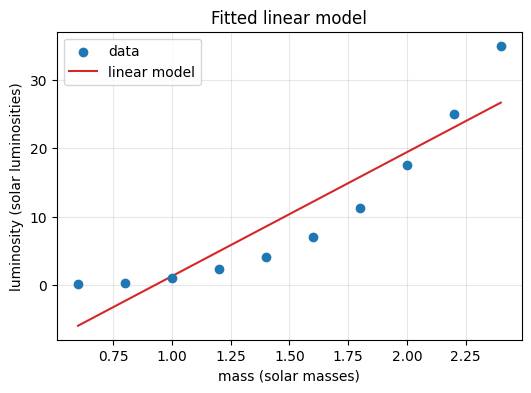

In [9]:
mass_grid = np.linspace(mass.min(), mass.max(), 200)
y_hat_lin_grid = predict(mass_grid.reshape(-1, 1), w_lin, b_lin)

plt.figure(figsize=(6, 4))
plt.scatter(mass, luminosity, color="tab:blue", label="data", zorder=3)
plt.plot(mass_grid, y_hat_lin_grid, color="tab:red", label="linear model")
plt.xlabel("mass (solar masses)")
plt.ylabel("luminosity (solar luminosities)")
plt.title("Fitted linear model")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Convergence:** the cost drops quickly and flattens well before 2000 iterations. With alpha=0.1 it doesn't diverge (I tried up to alpha=0.5 and it stays stable; at alpha=0.6 it already explodes). So gradient descent does converge to a minimum; this model's problem is not one of optimization.

**Systematic error:** the line is off across almost the whole curve.

- at mass=0.6 and 0.8 the line predicts NEGATIVE luminosity, which is physically impossible
- in the middle (mass 1.2 to 1.8) the line sits ABOVE the data
- at the top end (mass 2.2, 2.4) the line stays BELOW

That shaped (non-random) pattern is the classic signature of underfitting: the model is too simple for the real shape of the data, it lacks curvature. It's not a matter of needing more training, it's that the function family (straight lines) cannot represent this relationship, no matter how well we optimize w and b.

### 4.1 Convergence diagnostics (bonus)

The previous paragraph claims that alpha=0.1 converges, that it stays stable up to alpha=0.5, and that alpha=0.6 explodes. Let's show it with numbers and a plot instead of just asserting it: we run the same `gradient_descent` on `X_linear` with several learning rates and compare the cost curves.

In [10]:
alphas_test = [0.05, 0.1, 0.3, 0.5, 0.6]
iters_test = 60
histories = {}

for a in alphas_test:
    _, _, it_a, cost_a = gradient_descent(
        X_linear, luminosity, np.zeros(1), 0.0, a, iters_test
    )
    histories[a] = cost_a
    blew_up = not np.isfinite(cost_a[-1]) or cost_a[-1] > 1e6
    print(f"alpha={a:<4} -> cost after {iters_test} iter: {cost_a[-1]:.4g}"
          f"{'  <-- DIVERGES' if blew_up else ''}")

alpha=0.05 -> cost after 60 iter: 24.95
alpha=0.1  -> cost after 60 iter: 18.34
alpha=0.3  -> cost after 60 iter: 10.64
alpha=0.5  -> cost after 60 iter: 9.875
alpha=0.6  -> cost after 60 iter: 2.866e+06  <-- DIVERGES


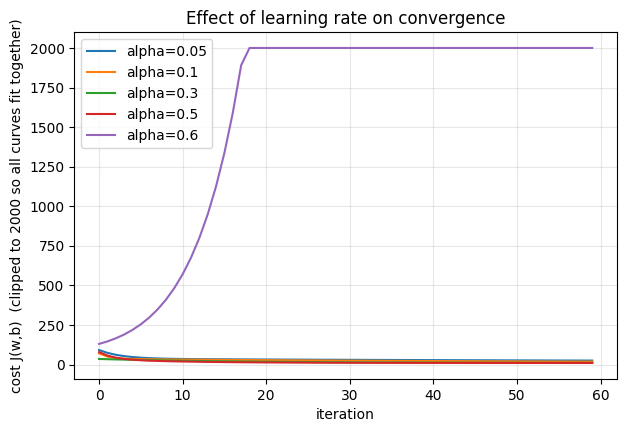

In [11]:
plt.figure(figsize=(7, 4.5))
for a, cost_a in histories.items():
    plt.plot(range(iters_test), np.clip(cost_a, 0, 2000), label=f"alpha={a}")
plt.xlabel("iteration")
plt.ylabel("cost J(w,b)  (clipped to 2000 so all curves fit together)")
plt.title("Effect of learning rate on convergence")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

With a small alpha (0.05) the cost goes down but slowly, it hasn't hit the floor yet after 60 iterations. Between 0.1 and 0.5 it converges fast and stays stable, those are the best candidates in this group. At alpha=0.6 the cost doesn't go down: it oscillates and grows out of control, the classic sign that the step size is too large and the algorithm overshoots the minimum on every iteration instead of approaching it. This confirms that the linear model's problem (section 4) was never one of optimization (gradient descent does find the minimum with a reasonable alpha) but of representation: the minimum it finds is still the best possible straight line, and a straight line isn't enough for this curve.

## 5. Polynomial model

Now we add `mass^2` as a new feature: `X_polynomial = [mass, mass^2]`.

`mass` and `mass^2` have very different scales (mass reaches 2.4, mass^2 reaches 5.76), so without scaling, gradient descent converges very slowly or requires a tiny alpha (I tested it: with alpha=0.1 unscaled the cost doesn't even fully converge in 20000 iterations). That's why here we DO scale the features (mean 0, standard deviation 1) before training.

The `predict` / `compute_cost` / `compute_gradient` / `gradient_descent` functions are EXACTLY the same ones from section 3, nothing was touched. The only thing that changes is the X matrix that goes in.

In [12]:
def feature_scale(X):
    """Standardizes each column of X to mean 0 and standard deviation 1."""
    means = X.mean(axis=0)
    stds = X.std(axis=0, ddof=0)
    X_scaled = (X - means) / stds
    return X_scaled, means, stds


X_polynomial = np.column_stack([mass, mass ** 2])
print("X_polynomial.shape:", X_polynomial.shape)
print(X_polynomial[:3])

X_poly_scaled, poly_means, poly_stds = feature_scale(X_polynomial)
print()
print("means:", poly_means)
print("std:  ", poly_stds)

X_polynomial.shape: (10, 2)
[[0.6  0.36]
 [0.8  0.64]
 [1.   1.  ]]

means: [1.5  2.58]
std:   [0.5745 1.7477]


In [13]:
n_poly = X_poly_scaled.shape[1]
w_init_poly = np.zeros(n_poly)
b_init_poly = 0.0

alpha_poly = 0.3
iters_poly = 3000

w_poly, b_poly, it_poly, cost_poly = gradient_descent(
    X_poly_scaled, luminosity, w_init_poly, b_init_poly, alpha_poly, iters_poly, print_every=300
)

print()
print("final w (scaled space):", w_poly)
print("final b:", b_poly)
print("final cost:", cost_poly[-1])

iter     0: cost =   42.0065
iter   300: cost =    0.7994
iter   600: cost =    0.3544
iter   900: cost =    0.3183
iter  1200: cost =    0.3154
iter  1500: cost =    0.3152
iter  1800: cost =    0.3151
iter  2100: cost =    0.3151
iter  2400: cost =    0.3151
iter  2700: cost =    0.3151
iter  2999: cost =    0.3151

final w (scaled space): [-15.4028  26.1824]
final b: 10.359999999999987
final cost: 0.31513333340756683


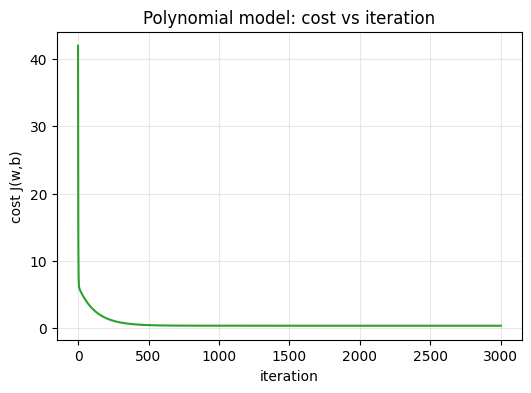

In [14]:
plt.figure(figsize=(6, 4))
plt.plot(it_poly, cost_poly, color="tab:green")
plt.xlabel("iteration")
plt.ylabel("cost J(w,b)")
plt.title("Polynomial model: cost vs iteration")
plt.grid(alpha=0.3)
plt.show()

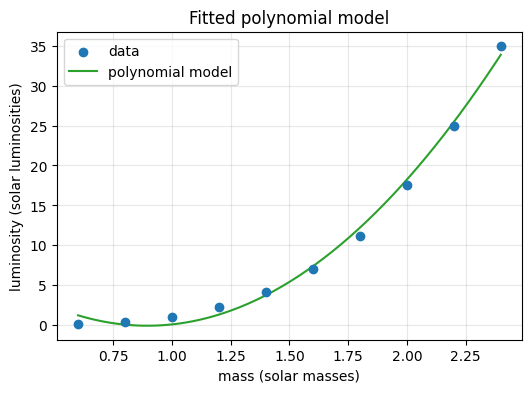

In [15]:
X_grid_poly = np.column_stack([mass_grid, mass_grid ** 2])
X_grid_poly_scaled = (X_grid_poly - poly_means) / poly_stds
y_hat_poly_grid = predict(X_grid_poly_scaled, w_poly, b_poly)

plt.figure(figsize=(6, 4))
plt.scatter(mass, luminosity, color="tab:blue", label="data", zorder=3)
plt.plot(mass_grid, y_hat_poly_grid, color="tab:green", label="polynomial model")
plt.xlabel("mass (solar masses)")
plt.ylabel("luminosity (solar luminosities)")
plt.title("Fitted polynomial model")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**What changed:**

- the input representation: X now has 2 columns (mass, mass^2) instead of 1
- we had to scale the features for gradient descent to converge well; the linear model didn't need it
- the final w's no longer read directly as "luminosity per solar mass", they live in the scaled space (so to predict on new data you first have to scale it with the SAME training means/std, see section 7)

**What did NOT change:**

- `predict`, `compute_cost`, `compute_gradient`, `gradient_descent`: all 4 functions are identical to section 3, not a single different line
- the dataset: same 10 points
- the algorithm's logic (iteratively descending the gradient) is the same

Adding curvature to the model was 100% a change in **features**, not a change in **algorithm**. That's basically what "feature engineering" is: the learning didn't change, what changed is that we gave the model a richer input representation.

## 6. Comparing both models

In [16]:
def mse(X, y, w, b):
    """True MSE (without the class convention's 1/2 factor), in luminosity^2 units."""
    error = predict(X, w, b) - y
    return np.mean(error ** 2)


mse_lin = mse(X_linear, luminosity, w_lin, b_lin)
mse_poly = mse(X_poly_scaled, luminosity, w_poly, b_poly)

print(f"linear     -> cost J = {cost_lin[-1]:.4f} | MSE = {mse_lin:.4f} | RMSE = {np.sqrt(mse_lin):.4f}")
print(f"polynomial -> cost J = {cost_poly[-1]:.4f} | MSE = {mse_poly:.4f} | RMSE = {np.sqrt(mse_poly):.4f}")
print()
print(f"the polynomial model reduces the MSE by a factor of ~{mse_lin / mse_poly:.1f}x")

linear     -> cost J = 9.7951 | MSE = 19.5903 | RMSE = 4.4261
polynomial -> cost J = 0.3151 | MSE = 0.6303 | RMSE = 0.7939

the polynomial model reduces the MSE by a factor of ~31.1x


In [17]:
residuals_lin = luminosity - predict(X_linear, w_lin, b_lin)
residuals_poly = luminosity - predict(X_poly_scaled, w_poly, b_poly)

print("linear residuals:    ", residuals_lin)
print("polynomial residuals:", residuals_poly)

linear residuals:     [ 6.1073  2.6812 -0.2948 -2.6209 -4.447  -5.173  -4.5991 -1.9252  1.9488
  8.3227]
polynomial residuals: [-1.0836  0.2843  0.9036  0.9745  0.347  -0.3791 -1.0036 -0.7267 -0.4482
  1.1318]


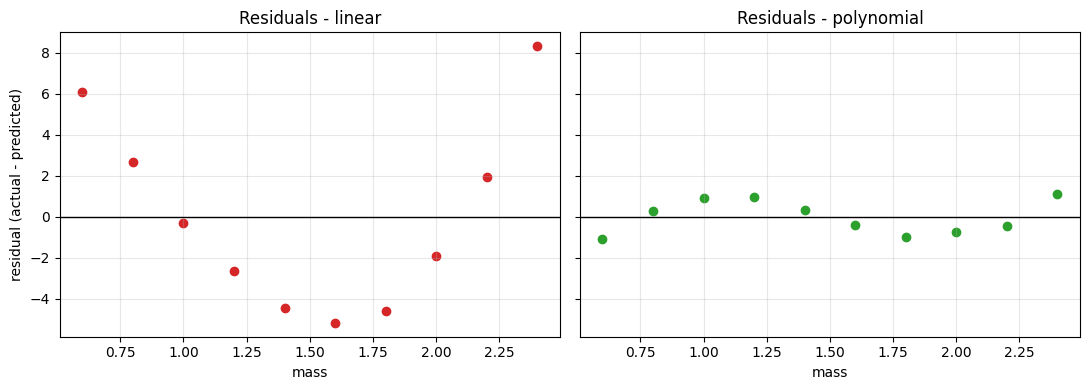

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

axes[0].axhline(0, color="black", linewidth=1)
axes[0].scatter(mass, residuals_lin, color="tab:red")
axes[0].set_title("Residuals - linear")
axes[0].set_xlabel("mass")
axes[0].set_ylabel("residual (actual - predicted)")
axes[0].grid(alpha=0.3)

axes[1].axhline(0, color="black", linewidth=1)
axes[1].scatter(mass, residuals_poly, color="tab:green")
axes[1].set_title("Residuals - polynomial")
axes[1].set_xlabel("mass")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

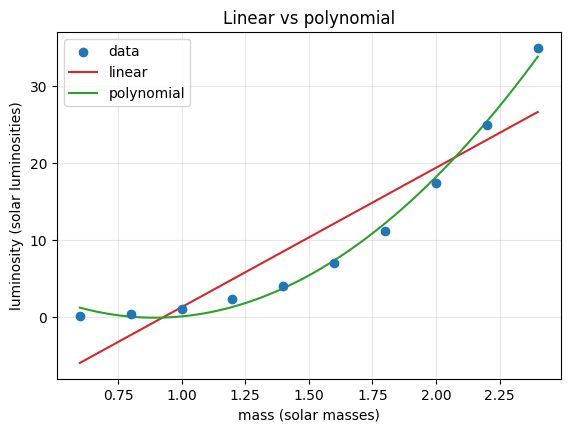

In [19]:
plt.figure(figsize=(6.5, 4.5))
plt.scatter(mass, luminosity, color="tab:blue", label="data", zorder=3)
plt.plot(mass_grid, y_hat_lin_grid, color="tab:red", label="linear")
plt.plot(mass_grid, y_hat_poly_grid, color="tab:green", label="polynomial")
plt.xlabel("mass (solar masses)")
plt.ylabel("luminosity (solar luminosities)")
plt.title("Linear vs polynomial")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The polynomial model clearly wins within the range we observed: cost J drops a lot (several times lower) and RMSE also drops sharply, from several solar luminosities of typical error down to less than one. The residual plots show the difference in shape: the linear model has that shaped pattern (negative at the extremes, positive in the middle, the inverted-U shape we already anticipated in section 2), while the polynomial has smaller residuals without such a marked pattern.

**Watch out for the trap:** a lower training error does NOT prove the polynomial model is "correct" in a scientific sense. It only proves the parabola fits THESE 10 points, which we already saw, better. With 10 data points and 3 free parameters (w1, w2, b) it's easy for a higher-capacity model to lower the training error; that's not evidence we captured the real physics of how luminosity scales with mass. To claim that we'd need more data, a train/test split, and a comparison against a real physical model (something like L ~ M^a) -- things this toy dataset doesn't let us do rigorously.

## 6.1 Bonus: reframing the problem (log-log regression)

The real mass-luminosity relation for main-sequence stars is approximately a **power law**: L = a * M^b. A power law is not linear in (M, L), but if we take the logarithm of both sides:

log(L) = log(a) + b * log(M)

...that IS linear, in the variables (log M, log L). Instead of adding features to the model (like we did with mass^2), we can transform the data and reuse the simplest linear model we already have, without touching `predict`, `compute_cost`, `compute_gradient` or `gradient_descent`. It's the same algorithm from section 4, applied to a different input representation.

In [20]:
log_mass = np.log(mass)
log_luminosity = np.log(luminosity)

X_log = log_mass.reshape(-1, 1)

w_log, b_log, it_log, cost_log = gradient_descent(
    X_log, log_luminosity, np.zeros(1), 0.0, alpha=0.3, num_iterations=3000, print_every=None
)

print("final w (slope in log scale):", w_log)
print("final b (intercept in log scale):", b_log)
print("final cost (in log scale):", cost_log[-1])
print()
print(f"Recovered exponent b: {w_log[0]:.3f}  (the real astrophysical value is around ~3.5 for Sun-like stars)")

final w (slope in log scale): [4.0383]
final b (intercept in log scale): 0.03737985361494028
final cost (in log scale): 0.002866895540448569

Recovered exponent b: 4.038  (the real astrophysical value is around ~3.5 for Sun-like stars)


In [21]:
# back to the original scale (luminosity, not log-luminosity) to compare in the same units
mass_grid_log = np.log(mass_grid)
y_hat_log_grid = np.exp(predict(mass_grid_log.reshape(-1, 1), w_log, b_log))

y_pred_log_train = np.exp(predict(X_log, w_log, b_log))
mse_log = np.mean((luminosity - y_pred_log_train) ** 2)

print(f"log-log    -> MSE (real luminosity units) = {mse_log:.4f} | RMSE = {np.sqrt(mse_log):.4f} | parameters = 2 (w, b)")
print(f"linear     -> MSE = {mse_lin:.4f} | RMSE = {np.sqrt(mse_lin):.4f} | parameters = 2 (w, b)")
print(f"polynomial -> MSE = {mse_poly:.4f} | RMSE = {np.sqrt(mse_poly):.4f} | parameters = 3 (w1, w2, b)")

log-log    -> MSE (real luminosity units) = 0.0617 | RMSE = 0.2485 | parameters = 2 (w, b)
linear     -> MSE = 19.5903 | RMSE = 4.4261 | parameters = 2 (w, b)
polynomial -> MSE = 0.6303 | RMSE = 0.7939 | parameters = 3 (w1, w2, b)


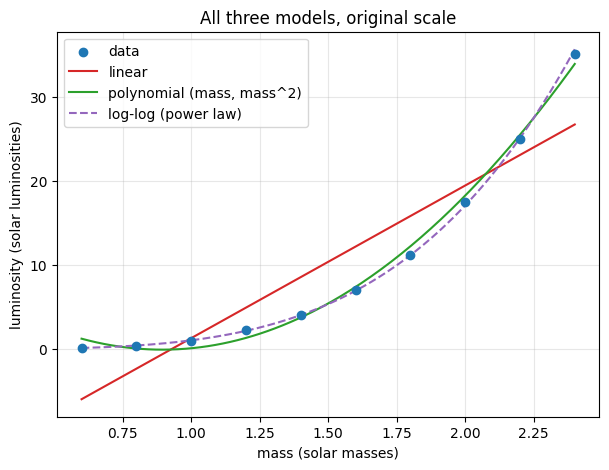

In [22]:
plt.figure(figsize=(7, 5))
plt.scatter(mass, luminosity, color="tab:blue", label="data", zorder=3)
plt.plot(mass_grid, y_hat_lin_grid, color="tab:red", label="linear")
plt.plot(mass_grid, y_hat_poly_grid, color="tab:green", label="polynomial (mass, mass^2)")
plt.plot(mass_grid, y_hat_log_grid, color="tab:purple", linestyle="--", label="log-log (power law)")
plt.xlabel("mass (solar masses)")
plt.ylabel("luminosity (solar luminosities)")
plt.title("All three models, original scale")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Why this matters:** on this dataset the log-log model doesn't just match the polynomial, it clearly beats it (MSE=0.062 vs 0.63 for the polynomial and 19.6 for the linear model, see previous cell) using ONE feature less (2 parameters instead of 3), because we gave the algorithm the correct functional form instead of asking it to approximate one with a parabola. The recovered exponent (b=4.04) also lands in the right order of magnitude for main-sequence stars (the real value is around ~3.5, and this dataset is synthetic, not observational, so an exact match isn't expected). The parabola mimics the curvature locally (well inside the 0.6-2.4 range) but has no physical reason to remain valid outside it; the log-log model IS grounded in the real shape of the physical law, so in principle it should extrapolate better (though with only 10 data points, confidence remains limited, see section 7).

This is the short, practical version of something already mentioned in section 5: **adding the correct representation is worth more than blindly adding capacity.** mass^2 was a reasonable bet without knowing the physics; log(mass) is an informed bet because we know (or suspect) the real shape of the relationship. That same principle -- choosing features informed by what's known about the problem, instead of just adding more parameters -- is one of the ideas we come back to in the AI reflection (section 8, question 3).

### Summary table of the three models

| Model | X representation | Parameters | MSE | RMSE |
|---|---|---|---|---|
| Linear | `[mass]` | 2 (w, b) | 19.590 | 4.426 |
| Polynomial | `[mass, mass^2]` | 3 (w1, w2, b) | 0.630 | 0.794 |
| Log-log (bonus) | `[log(mass)]` | 2 (w, b) | 0.062 | 0.248 |

The log-log model wins on all three columns that matter (lower error, fewer parameters) precisely because the representation matches the real physics of the problem. This doesn't invalidate the polynomial exercise -- it's still the representation the assignment asked for and a real improvement over the line -- but it leaves a clear lesson for the reflection section: more capacity (mass^2) helps even without knowing the physics, but the correct representation (log-log, informed by domain knowledge) beats blindly adding capacity.

## 7. How far a prediction can be trusted

We test both models at two points: `mass=1.3` (inside the observed range) and `mass=5.0` (well outside it, the maximum we saw was 2.4).

In [23]:
mass_query = np.array([1.3, 5.0])

# linear
X_query_lin = mass_query.reshape(-1, 1)
y_query_lin = predict(X_query_lin, w_lin, b_lin)

# polynomial: need to build mass^2 and scale with the SAME training means/std
X_query_poly = np.column_stack([mass_query, mass_query ** 2])
X_query_poly_scaled = (X_query_poly - poly_means) / poly_stds
y_query_poly = predict(X_query_poly_scaled, w_poly, b_poly)

for i, mq in enumerate(mass_query):
    print(f"mass = {mq}")
    print(f"  linear prediction:     {y_query_lin[i]:9.3f}")
    print(f"  polynomial prediction: {y_query_poly[i]:9.3f}")
    print()

mass = 1.3
  linear prediction:         6.734
  polynomial prediction:     2.389

mass = 5.0
  linear prediction:        73.816
  polynomial prediction:   252.390



In [24]:
# how far each query point is from what the model actually saw,
# measured in standard deviations of the scaled feature (z-score)
print("z-scores (mass, mass^2) for each query point:")
print(X_query_poly_scaled)
print()
print("mass range observed in training:", mass.min(), "-", mass.max())

z-scores (mass, mass^2) for each query point:
[[-0.3482 -0.5092]
 [ 6.0927 12.8282]]

mass range observed in training: 0.6 - 2.4


**mass=1.3** is INSIDE the observed range (between 1.2 and 1.4, there are close neighbors on both sides). The z-scores are close to 0 (less than half a standard deviation). There, both predictions are genuine interpolation. The polynomial model is more credible because its immediate neighbors (predicted at mass=1.2 and 1.4) also fall close to that zone, while we'd already seen the line overestimate exactly in that part of the curve (sections 4 and 6).

**mass=5.0** is way OUTSIDE the range (the maximum we saw was 2.4). The z-scores shoot past 6 standard deviations for mass and past 12 for mass^2: the polynomial model never saw anything remotely like this during training. Both predictions also blow up, but neither has real support in the data:

- the line extrapolates assuming the slope stays constant forever, and we already know that's false (the real relationship is curved)
- the parabola extrapolates assuming the curvature learned between 0.6 and 2.4 keeps holding all the way to 5.0, but a parabola grows without bound and nothing in the data tells us the real luminosity keeps that exact shape beyond mass=2.4 (in real life the mass-luminosity relation even changes exponent across different mass ranges)

**Short conclusion:** trusting the mass=1.3 prediction is reasonable, it's interpolation with nearby data. Trusting mass=5.0 is NOT reasonable with either model: no matter how much "better" the parabola looks, we're still extrapolating far beyond all the evidence we have.

## 8. Reflection on AI

Questions from the assignment, answered after finishing the technical work.

### 1. What does this experiment reveal -- and what does it fail to reveal -- about how more advanced AI systems learn?

It reveals things that DO generalize: defining a cost function, computing a gradient, and descending it iteratively is literally what a large neural network does (GPT and friends), just with vastly more parameters and with backpropagation instead of a gradient I derived by hand. It also reveals something key: a model only learns what the shape of its features allows it to learn (the line was never going to manage it, no matter how long it trained, because the function family isn't expressive enough), and that adding capacity (the polynomial) lowers training error but that's not the same as "understanding" the physics of stars.

What it does NOT reveal: there's nothing here of what makes today's large models impressive. No generalization to new tasks, no learned representations of text or images, no attention or memory, no scale (10 data points vs. billions of tokens), none of the "emergence" phenomena seen in large LLMs. This notebook is the mathematical foundation (gradient descent) that those systems build on, but the distance between this and a large language model is enormous.

### 2. Is Artificial General Intelligence (AGI) achievable?

To me, AGI would be a system capable of learning and performing well on new cognitive tasks it has never seen, with the same flexibility as a human (not just the specific task it was trained for) -- including reasoning about genuinely novel problems and transferring what it learned across different domains without a human having to redesign the system for each new task.

I think it's achievable in principle: I don't see a physical or mathematical reason that rules it out; the human brain is already evidence that "matter organized in a certain way produces general intelligence" is possible. But I don't think we're close, nor that it's just a matter of a short amount of time. Current systems are still very good at interpolating within the data distribution they saw (exactly like my polynomial model at mass=1.3) and fairly bad at genuinely extrapolating to new situations (like mass=5.0). That interpolation-vs-extrapolation gap we saw in miniature with 10 points seems to me, at a different scale, basically the same problem separating today's LLMs from something one would call AGI.

### 3. Could AGI emerge just from scaling (more GPUs, more data, more parameters), or is something fundamentally different needed?

My opinion is that scaling alone isn't enough, even though it helps enormously (the last few years proved that: things "emerge" with scale that nobody predicted beforehand). But scaling is basically like making my polynomial model degree 1000 instead of degree 2: it lowers training error further, it fits what it has already seen better, but it doesn't by itself solve the problem of what structure to give the model so it generalizes well outside the distribution. In my example, no amount of extra iterations was going to make the line learn the curvature, because the limit wasn't optimization but representation (which features I give it). We saw it again, in miniature, in section 6.1: the log-log model (2 parameters, the correct representation) clearly beat the polynomial (3 parameters, more capacity but blind) -- more parameters didn't make up for lacking the correct functional form.

I suspect a combination is needed: more scale DOES help, but so do better mechanisms for step-by-step reasoning, real memory or persistent state, ways of interacting with the world (not just text) to learn causality and not just correlation, and probably learning mechanisms different from "predict the next token" for some capabilities. I don't think it's "just scale" nor that "everything needs to be reinvented from scratch": it's probably a bit of both.

### 4. One question about AI-driven systems that I want to explore during the semester:

Without being able to look "inside" the model, how do I know whether an AI system's prediction is reliable interpolation (like my mass=1.3) or extrapolation in disguise (like my mass=5.0)? In other words, is there a practical way to measure how far an input is from what the model actually saw during training, for giant models where I can no longer just plot the 10 points like I did here?